<br>
<a href="https://github.com/aperture-systems-lab">
    <img src="assets/banner_semillero.png" width="955" style="margin: 0px 0px 12px;"/>
</a>
<h1 style="line-height: 1.4;"><font color="#29c4d9"><b>Cómo funcionan las redes neuronales</b></font></h1>
<h2><b>Notebook 2: </b>Clasificación</h2>

In [10]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import utils

torch.manual_seed(42)

----

<br>

## **Parte 0:** Nuestro objetivo

<div style="float: right; width: 36%; min-width: 170px; max-width: 300px; margin: 4px 0px 12px 30px;">
  <img src="assets/titanic.png" width="100%" alt="Hundimiento del titanic"
       style="display: block; transform: rotate(-1.5deg);
              filter: drop-shadow(0px 12px 20px rgba(41, 196, 217, 0.35));"/>
</div>

----

<br>

## **Parte 1:** Los datos

In [11]:
train_df = pd.read_csv("data/titanic/train.csv")
test_df = pd.read_csv("data/titanic/test.csv")

pasajeros_raw = pd.concat([train_df, test_df], ignore_index=True)

print("dimensiones:", pasajeros_raw.shape)
pasajeros_raw.head()

dimensiones: (1309, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


----

<br>

## **Parte 2:** Preparación de los datos

In [12]:
def preprocess(df):
    df = df.copy()

    def normalize_name(x):
        return " ".join([v.strip(",()[].\"'") for v in x.split(" ")])

    def ticket_number(x):
        return x.split(" ")[-1]

    def ticket_item(x):
        items = x.split(" ")
        if len(items) == 1:
            return "NONE"
        return "_".join(items[0:-1])

    df["Name"] = df["Name"].apply(normalize_name)
    df["Ticket_number"] = df["Ticket"].apply(ticket_number)
    df["Ticket_item"] = df["Ticket"].apply(ticket_item)
    return df


preprocessed_df = preprocess(train_df)

input_features = list(preprocessed_df.columns)
input_features.remove("Ticket")
input_features.remove("PassengerId")
input_features.remove("Survived")
input_features.remove("Name")

print(f"Input features: {input_features}")
preprocessed_df.head(5)

Input features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked', 'Ticket_number', 'Ticket_item']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item
0,1,0,3,Braund Mr Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S,21171,A/5
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC
2,3,1,3,Heikkinen Miss Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3101282,STON/O2.
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE
4,5,0,3,Allen Mr William Henry,male,35.0,0,0,373450,8.0500,NaN,S,373450,NONE


In [13]:
preprocessed_train_df, preprocessed_serving_df = train_test_split(
    preprocessed_df,
    test_size=0.2,
    random_state=42
)

print(f"{len(preprocessed_train_df)} ejemplos de entrenamiento, {len(preprocessed_serving_df)} ejemplos de prueba.")

712 ejemplos de entrenamiento, 179 ejemplos de prueba.


In [ ]:
def to_tensors(df, input_features):
    df = df[input_features + ["Survived"]].copy()

    df = df.fillna({"Age": df["Age"].median(), "Fare": df["Fare"].median(),"Embarked": "S", "Cabin": "NONE"})

    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = pd.factorize(df[col])[0]

    X = torch.tensor(df[input_features].values, dtype=torch.float32)
    y = torch.tensor(df["Survived"].values, dtype=torch.float32).unsqueeze(1)
    return X, y


X_train, y_train = to_tensors(preprocessed_train_df, input_features)
X_val, y_val = to_tensors(preprocessed_serving_df, input_features)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: torch.Size([712, 10])
y_train shape: torch.Size([712, 1])


----

<br>

## **Parte 4:** La red

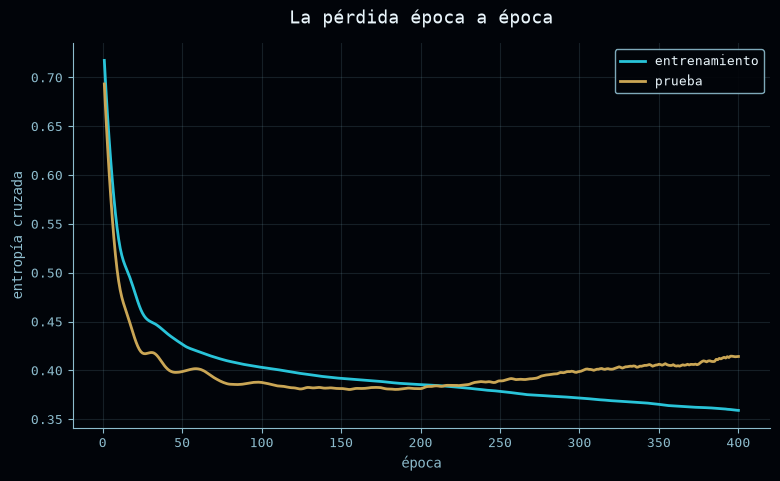

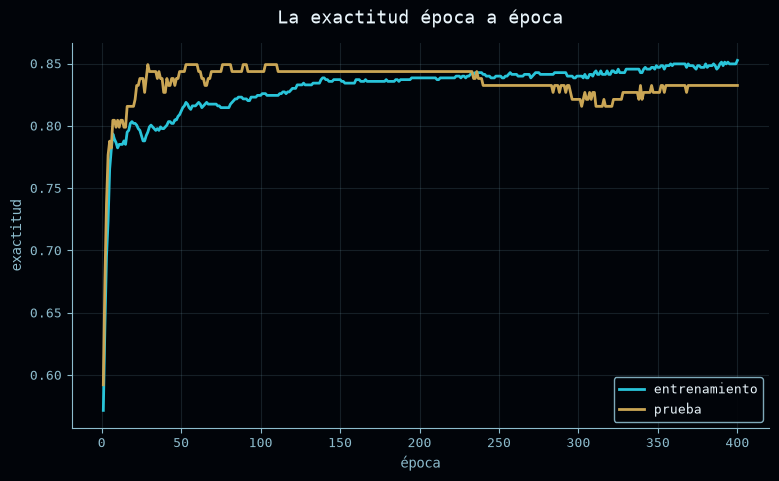

In [ ]:
utils.dibujar_metricas(perdidas, titulo="La pérdida época a época", y_etiqueta="entropía cruzada")
utils.dibujar_metricas(exactitudes, titulo="La exactitud época a época", y_etiqueta="exactitud")

In [ ]:
print(f"exactitud en entrenamiento: {exactitud(modelo, x_entrenar_n, y_entrenar):.3f}")
print(f"exactitud en prueba      : {exactitud(modelo, x_prueba_n, y_prueba):.3f}")
print(f"decir que todos mueren    : {1 - y_prueba.float().mean().item():.3f}  <- el mínimo a superar")

exactitud en entrenamiento: 0.853
exactitud en prueba      : 0.832
decir que todos mueren    : 0.704  <- el mínimo a superar


In [ ]:
with torch.no_grad():
    elegida = modelo(x_prueba_n).argmax(dim=1)

matriz = torch.zeros(2, 2, dtype=torch.long)
for real, predicha in zip(y_prueba, elegida):
    matriz[real, predicha] += 1

print("filas: lo que pasó | columnas: lo que dijo la red\n")
print(pd.DataFrame(matriz.numpy(),
                   index=["murió", "sobrevivió"],
                   columns=["dijo murió", "dijo sobrevivió"]))

filas: lo que pasó | columnas: lo que dijo la red

            dijo murió  dijo sobrevivió
murió              118                8
sobrevivió          22               31


-----

<br>

### **Siguiente notebook:**

[`03_tictactoe.ipynb`](03_tictactoe.ipynb)

### <font color="#29c4d9">**Notebook 2 listo.**</font>

<br>

---

<div style="margin-top: 50px;"><center><a href="https://github.com/aperture-systems-lab"><img src="assets/banner_logo.png" width="955"/></a></center></div>